**#Case Study 1**

# PART A: Preprocess the data

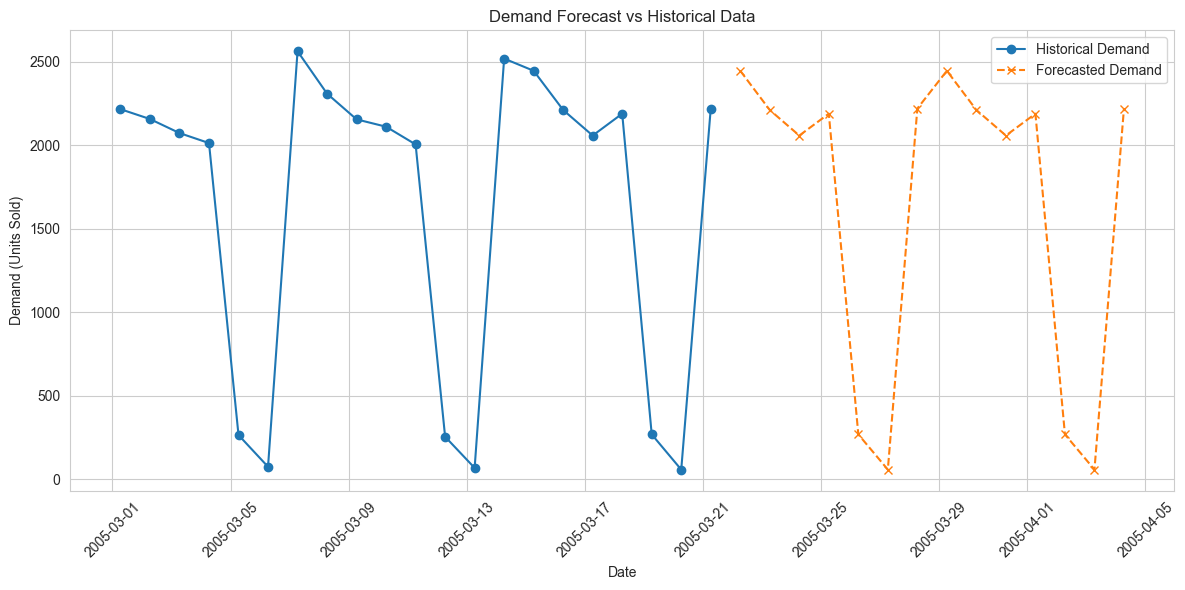

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the file
df = pd.read_csv("C:\\Users\\hangu\\Downloads\\bicup2006.csv")

# Combine 'DATE' and 'TIME' columns into a single 'DATE_TIME' column
df['DATE_TIME'] = df['DATE'] + ' ' + df['TIME']

# Convert 'DATE_TIME' column to datetime objects
df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'], format='%d-%b-%y %H:%M')

# Group by date and aggregate sum 'DEMAND'
df_agg = df.groupby(df['DATE_TIME'].dt.date).agg(
    DEMAND=('DEMAND', 'sum'),
    TIME=('DATE_TIME', 'min')
).reset_index()

# Rename the date column back to 'DATE'
df_agg = df_agg.rename(columns={'DATE_TIME': 'DATE'})

# Combine the aggregated date and the earliest time back into a single datetime column
df_agg['DATETIME'] = pd.to_datetime(df_agg['DATE'].astype(str) + ' ' + df_agg['TIME'].dt.strftime('%H:%M'))

# Set 'DATETIME' as the index
df_time_series = df_agg.set_index('DATETIME')

# Drop the original 'DATE' and 'TIME' columns
df_time_series = df_time_series.drop(columns=['DATE', 'TIME'])


# Set the plot style
sns.set_style("whitegrid")

# Get the last 7 days of data to use as the seasonal pattern
last_week_demand = df_time_series['DEMAND'][-7:]

# Generate the dates for the next 14 days
forecast_dates = pd.date_range(start=df_time_series.index[-1] + pd.Timedelta(days=1), periods=14, freq='D')

# Create the forecast by repeating the last week's pattern twice
forecast_values = list(last_week_demand) * 2

# Create a DataFrame for the forecast
forecast_df = pd.DataFrame({'DATE': forecast_dates, 'FORECAST_DEMAND': forecast_values})

# Set Date as index
forecast_df = forecast_df.set_index('DATE')

# Plot the graph
plt.figure(figsize=(12, 6))
plt.plot(df_time_series.index, df_time_series['DEMAND'], marker='o', linestyle='-', label='Historical Demand')
plt.plot(forecast_df.index, forecast_df['FORECAST_DEMAND'], marker='x', linestyle='--', label='Forecasted Demand')

# Add titles and labels
plt.title('Demand Forecast vs Historical Data')
plt.xlabel('Date')
plt.ylabel('Demand (Units Sold)')
plt.legend()

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Prepare the plot to be shown
plt.tight_layout()
plt.show()

#### Technical Checkpoint 1:
##### Q1. What kind of problems can arise if we do not handle missing time steps in time series data?
##### If we do not handle missing time steps in time series data, it can lead to misinterpretation, incorrect data analysis and predictions, therefore affecting decision making processes. The models expect data at regular intervals, such as every 15 minutes or every day, every week, etc.  Missing steps will cause the data to be less in amount, less accurate. Furthermore, missing data can lead to incorrect trends or patterns, eventually lead to incorrect forecasts and affect our decision making.

##### Q2. How would differencing help here, and how do you detect the correct level of differencing needed
##### Differencing will try to fix this interruption by removing trends and making the data more stable. It does so by subtracting the previous value from the current value, to eliminate the trends and stabilize the mean.
##### To find the right amount, we can use the Augmented Dickey-Fuller (ADF) test to check if the data is stable. We can look at the p-value to tell. If the p value < 0.05, that means it is stable and good to continue.


# Part B: Stationarity Check with ADF Test

--- ADF Test Results ---
ADF Statistic: -0.9055485861037496
p-value: 0.7861396971364512

Interpretation:
Fail to reject the null hypothesis (H0). The series is likely non-stationary.
-------------------------

Plotting Rolling Statistics...


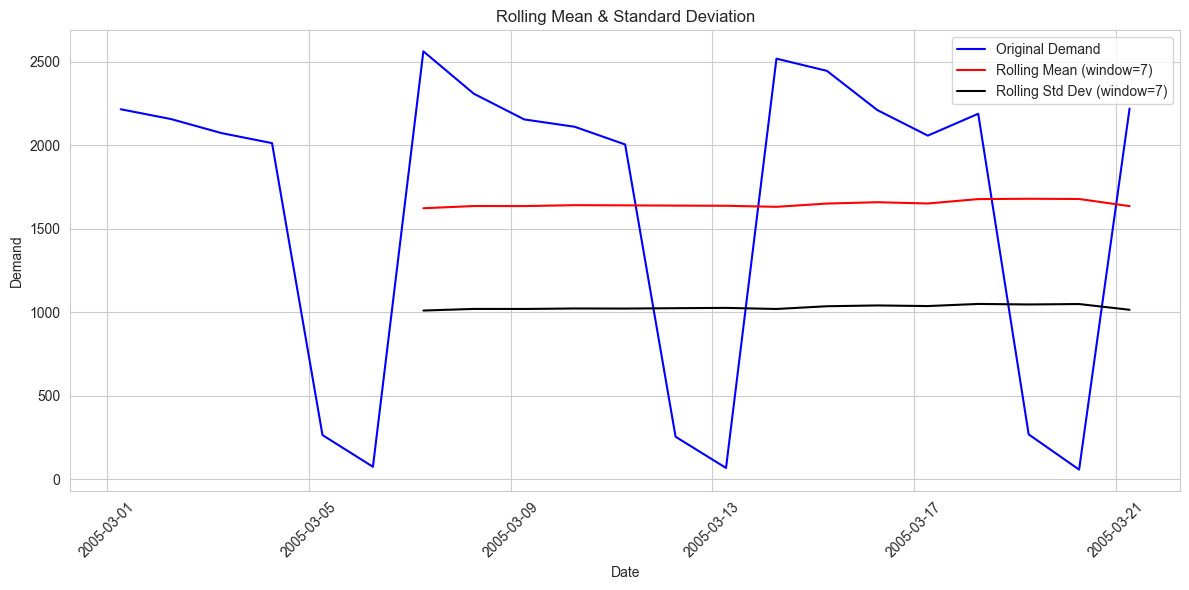

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller

# A.Preprocessing Code
# Load the file
df = pd.read_csv("C:\\Users\\hangu\\Downloads\\bicup2006.csv")

# Combine 'DATE' and 'TIME' columns into a single 'DATE_TIME' column
df['DATE_TIME'] = df['DATE'] + ' ' + df['TIME']

# Convert 'DATE_TIME' column to datetime objects
df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'], format='%d-%b-%y %H:%M')

# Group by date and aggregate sum 'DEMAND'
df_agg = df.groupby(df['DATE_TIME'].dt.date).agg(
    DEMAND=('DEMAND', 'sum'),
    TIME=('DATE_TIME', 'min')
).reset_index()

# Rename the date column back to 'DATE'
df_agg = df_agg.rename(columns={'DATE_TIME': 'DATE'})

# Combine the aggregated date and the earliest time back into a single datetime column
df_agg['DATETIME'] = pd.to_datetime(df_agg['DATE'].astype(str) + ' ' + df_agg['TIME'].dt.strftime('%H:%M'))

# Set 'DATETIME' as the index
df_time_series = df_agg.set_index('DATETIME')

# Drop the original 'DATE' and 'TIME' columns
df_time_series = df_time_series.drop(columns=['DATE', 'TIME'])

# Stationarity Check

# Augmented Dickey-Fuller (ADF) Test
adf_result = adfuller(df_time_series['DEMAND'])

# Extract and print results
adf_statistic = adf_result[0]
p_value = adf_result[1]
print(f'ADF Statistic: {adf_statistic}')
print(f'p-value: {p_value}')

# Interpretation
print("\nInterpretation:")
if p_value <= 0.05:
    print("The data is likely stationary.")
else:
    print("The data is likely non-stationary.")
print("-" * 25)


# 2. Plot Rolling Mean and Standard Deviation
print("\nPlotting Rolling Statistics...")
# Define window size
window_size = 7

# Calculate rolling mean and std deviation
rolling_mean = df_time_series['DEMAND'].rolling(window=window_size).mean()
rolling_std = df_time_series['DEMAND'].rolling(window=window_size).std()

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(df_time_series['DEMAND'], color='blue', label='Original Demand')
plt.plot(rolling_mean, color='red', label=f'Rolling Mean (window={window_size})')
plt.plot(rolling_std, color='black', label=f'Rolling Std Dev (window={window_size})')

# Add titles and labels
plt.title('Rolling Mean & Standard Deviation')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.legend(loc='best')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Calculating and Plotting Rolling Statistics...


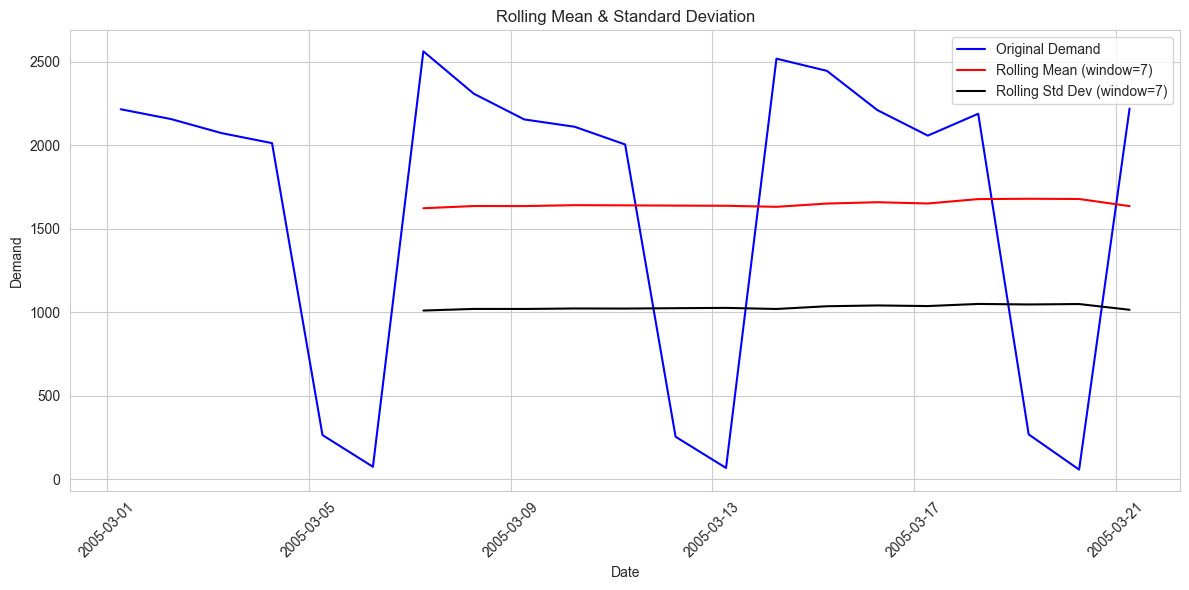

Plotting code is ready.


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data set
df = pd.read_csv("C:\\Users\\hangu\\Downloads\\bicup2006.csv")

# Combine 'DATE' and 'TIME' columns into a single 'DATE_TIME' column
df['DATE_TIME'] = df['DATE'] + ' ' + df['TIME']

# Convert 'DATE_TIME' column to datetime objects
df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'], format='%d-%b-%y %H:%M')

# Group by date and aggregate sum 'DEMAND'
df_agg = df.groupby(df['DATE_TIME'].dt.date).agg(
    DEMAND=('DEMAND', 'sum'),
    TIME=('DATE_TIME', 'min')
).reset_index()

# Rename the date column back to 'DATE'
df_agg = df_agg.rename(columns={'DATE_TIME': 'DATE'})

# Combine the aggregated date and the earliest time back into a single datetime column
df_agg['DATETIME'] = pd.to_datetime(df_agg['DATE'].astype(str) + ' ' + df_agg['TIME'].dt.strftime('%H:%M'))

# Set 'DATETIME' as the index
df_time_series = df_agg.set_index('DATETIME')

# Drop the original 'DATE' and 'TIME' columns
df_time_series = df_time_series.drop(columns=['DATE', 'TIME'])

# 2. Rolling Mean & Standard Deviation Plot Visualization Code

print("\nCalculating and Plotting Rolling Statistics...")
# Define window size
window_size = 7

# Calculate rolling mean and std deviation
rolling_mean = df_time_series['DEMAND'].rolling(window=window_size).mean()
rolling_std = df_time_series['DEMAND'].rolling(window=window_size).std()

# Set plot style
sns.set_style("whitegrid")

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(df_time_series['DEMAND'], color='blue', label='Original Demand')
plt.plot(rolling_mean, color='red', label=f'Rolling Mean (window={window_size})')
plt.plot(rolling_std, color='black', label=f'Rolling Std Dev (window={window_size})')

# Add titles and labels
plt.title('Rolling Mean & Standard Deviation')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.legend(loc='best')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Ensure layout is neat
plt.tight_layout()

# Show the plot
plt.show()

print("Plotting code is ready.")


Performing Seasonal Decomposition...
Plotting decomposition results (Model=additive, Period=7)...


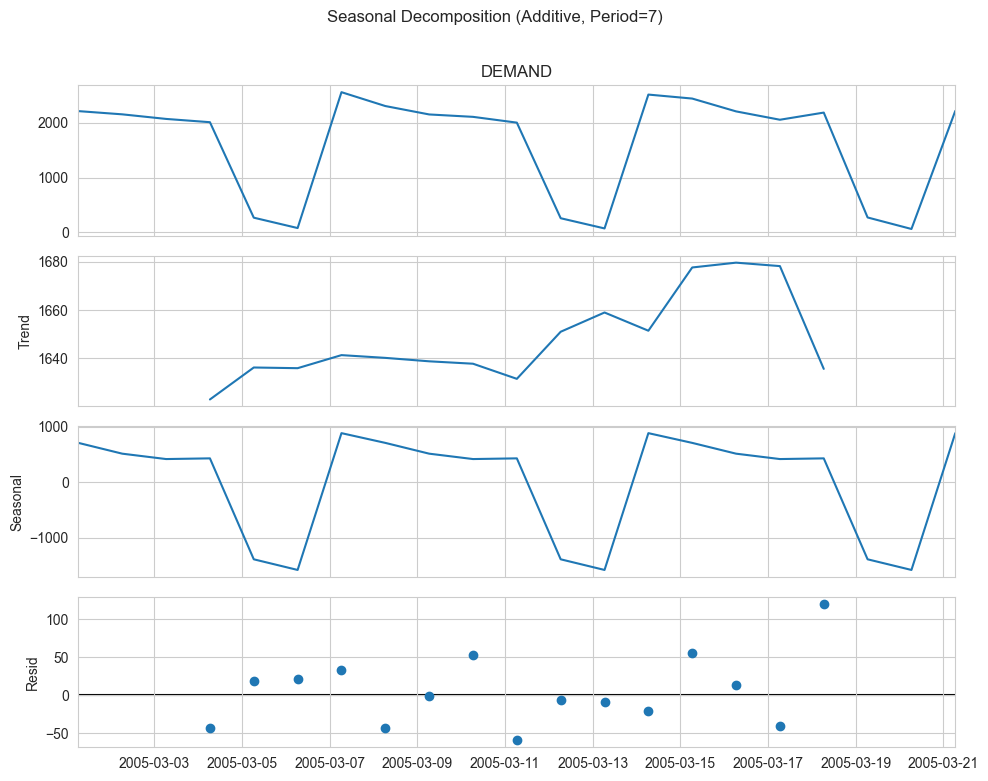


Decomposition successful and plot prepared.


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose


# Load the file
df = pd.read_csv("C:\\Users\\hangu\\Downloads\\bicup2006.csv")

# Combine 'DATE' and 'TIME' columns into a single 'DATE_TIME' column
df['DATE_TIME'] = df['DATE'] + ' ' + df['TIME']

# Convert 'DATE_TIME' column to datetime objects
df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'], format='%d-%b-%y %H:%M')

# Group by date and aggregate sum 'DEMAND'
df_agg = df.groupby(df['DATE_TIME'].dt.date).agg(
    DEMAND=('DEMAND', 'sum'),
    TIME=('DATE_TIME', 'min')
).reset_index()

# Rename the date column back to 'DATE'
df_agg = df_agg.rename(columns={'DATE_TIME': 'DATE'})

# Combine the aggregated date and the earliest time back into a single datetime column
df_agg['DATETIME'] = pd.to_datetime(df_agg['DATE'].astype(str) + ' ' + df_agg['TIME'].dt.strftime('%H:%M'))

# Set 'DATETIME' as the index
df_time_series = df_agg.set_index('DATETIME')

# Drop the original 'DATE' and 'TIME' columns
df_time_series = df_time_series.drop(columns=['DATE', 'TIME'])

# 3. Seasonal Decomposition Code

print("\nPerforming Seasonal Decomposition...")

# Define the seasonal period
seasonal_period = 7
# Choose model type
model_type = 'additive'

try:
    # Perform decomposition
    decomposition = seasonal_decompose(
        df_time_series['DEMAND'],
        model=model_type,
        period=seasonal_period
    )

    # Plot decomposition results
    print(f"Plotting decomposition results (Model={model_type}, Period={seasonal_period})...")
    fig = decomposition.plot()
    fig.set_size_inches(10, 8)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.suptitle(f'Seasonal Decomposition ({model_type.capitalize()}, Period={seasonal_period})', y=1.0)
    plt.show()


    print("\nDecomposition successful and plot prepared.")

except ValueError as e:
    print(f"\nDecomposition failed: {e}")
    print("This often happens if the time series is too short for the specified period.")

#### Technical Checkpoint 2
##### Q3. Why is stationarity important for ARIMA-type models?
# ARIMA models need stationarity; they require mean, variance and autocorrelation of the past data to remain constant overtime to predict the future. If the data keeps changing, that means it’s harder to guess the pattern for future predictions.

##### Q4. When would you use additive decomposition over multiplicative decomposition?
# Additive decomposition is used when the seasonal variations remain constant regardless of the overall trend, while multiplicative decomposition is suitable for situations where the seasonal fluctuations are proportional to the level of the trend.



# Part C & D: Forecasting Models & Model Evaluation

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings("ignore")

# Preprocessing Code
# Load the file
df = pd.read_csv("C:\\Users\\hangu\\Downloads\\bicup2006.csv")
df['DATE_TIME'] = df['DATE'] + ' ' + df['TIME']
df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'], format='%d-%b-%y %H:%M')
df_agg = df.groupby(df['DATE_TIME'].dt.date).agg(
    DEMAND=('DEMAND', 'sum'),
    TIME=('DATE_TIME', 'min')
).reset_index()
df_agg = df_agg.rename(columns={'DATE_TIME': 'DATE'})
df_agg['DATETIME'] = pd.to_datetime(df_agg['DATE'].astype(str) + ' ' + df_agg['TIME'].dt.strftime('%H:%M'))
# Ensure the index is a DatetimeIndex and set frequency if possible
df_time_series = df_agg.set_index('DATETIME').drop(columns=['DATE', 'TIME']).asfreq('D')

# Train/Test Split. Do 80/20 for train/test split
n_total = len(df_time_series)
n_train = 17
n_test = n_total - n_train

metrics_summary_df = pd.DataFrame()

# Check if split is minimally feasible
if n_train < 14 or n_test < 1:
     print(f"ERROR: Not enough data for a meaningful train/test split (Train: {n_train}, Test: {n_test}). Cannot proceed with evaluation.")
else:
    train_data = df_time_series.iloc[:n_train]
    test_data = df_time_series.iloc[n_train:]
    print(f"--- Train/Test Split ---")
    print(f"Train set size: {len(train_data)} points")
    print(f"Test set size: {len(test_data)} points")
    print("-" * 25)

    # Model Training & Forecasting on Test Set Period
    forecasts = {}

    # 1. SARIMA
    sarima_order = (1, 1, 0)
    sarima_seasonal_order = (1, 1, 0, 7)
    print(f"\nAttempting SARIMA{sarima_order}x{sarima_seasonal_order} on training data...")
    try:
        sarima_model_train = SARIMAX(train_data['DEMAND'], order=sarima_order, seasonal_order=sarima_seasonal_order, enforce_stationarity=False, enforce_invertibility=False)
        sarima_results_train = sarima_model_train.fit(disp=False)
        forecast_values = sarima_results_train.forecast(steps=n_test)
        forecasts['SARIMA'] = forecast_values
        print("SARIMA fitting and forecasting successful.")
    except Exception as e:
        print(f"SARIMA failed: {e}. Assigning NaN forecast.")
        forecasts['SARIMA'] = pd.Series(np.nan, index=test_data.index) # Ensure index matches test set

    # 2. Holt-Winters Exponential Smoothing
    print("\nAttempting Holt-Winters Exponential Smoothing on training data...")
    try:
        # Using simple heuristic initialization for stability on small data
        hw_model_train = ExponentialSmoothing(train_data['DEMAND'], trend='add', seasonal='add', seasonal_periods=7, initialization_method='heuristic')
        hw_results_train = hw_model_train.fit()
        forecast_values = hw_results_train.forecast(steps=n_test)
        forecasts['HoltWinters'] = forecast_values
        print("Holt-Winters fitting and forecasting successful.")
    except Exception as e:
        print(f"Holt-Winters failed: {e}. Assigning NaN forecast.")
        forecasts['HoltWinters'] = pd.Series(np.nan, index=test_data.index)

    # 3. Seasonal Naive Method
    print("\nGenerating Seasonal Naive forecast based on training data...")
    if len(train_data) >= 7:
        last_train_week_demand = train_data['DEMAND'][-7:]
        naive_forecast_list = list(last_train_week_demand) * (n_test // 7 + (n_test % 7 > 0))
        forecast_values = pd.Series(naive_forecast_list[:n_test], index=test_data.index)
        forecasts['SeasonalNaive'] = forecast_values
        print("Seasonal Naive forecast generated.")
    else:
        print("Not enough training data for Seasonal Naive (need >= 7). Assigning NaN forecast.")
        forecasts['SeasonalNaive'] = pd.Series(np.nan, index=test_data.index)


    #Evaluate Forecasts on Test Set
    print("\n--- Evaluation Metrics on Test Set ---")
    actual_values = test_data['DEMAND']
    results_list = []

    for model_name, forecast_values in forecasts.items():
        model_metrics = {"Model": model_name}
        # Check if forecast is all NaN
        if forecast_values.isnull().all():
            print(f"{model_name}: Model failed or produced NaN forecast.")
            model_metrics.update({"MAE": np.nan, "MSE": np.nan, "RMSE": np.nan})
        else:
            # Ensure indices align for calculation
            aligned_actual, aligned_forecast = actual_values.align(forecast_values, join='inner')
            if not aligned_forecast.empty:
                 mae = mean_absolute_error(aligned_actual, aligned_forecast)
                 mse = mean_squared_error(aligned_actual, aligned_forecast)
                 rmse = np.sqrt(mse)
                 print(f"{model_name} -> MAE: {mae:.2f}, MSE: {mse:.2f}, RMSE: {rmse:.2f}")
                 model_metrics.update({"MAE": mae, "MSE": mse, "RMSE": rmse})
            else:
                 print(f"{model_name}: Forecast alignment failed.")
                 model_metrics.update({"MAE": np.nan, "MSE": np.nan, "RMSE": np.nan})
        results_list.append(model_metrics)

    metrics_summary_df = pd.DataFrame(results_list)
    print("\n--- Summary Table ---")
    print(metrics_summary_df.to_markdown(index=False, floatfmt=".2f"))

    print("\nWARNING: Evaluation based on only 4 test points is highly unreliable.")
    print("-" * 25)

# Final check using the corrected DataFrame method '.empty'
if metrics_summary_df.empty:
     print("\nNo evaluation metrics generated, likely due to insufficient data for train/test split.")

--- Train/Test Split ---
Train set size: 17 points
Test set size: 4 points
-------------------------

Attempting SARIMA(1, 1, 0)x(1, 1, 0, 7) on training data...
SARIMA fitting and forecasting successful.

Attempting Holt-Winters Exponential Smoothing on training data...
Holt-Winters fitting and forecasting successful.

Generating Seasonal Naive forecast based on training data...
Seasonal Naive forecast generated.

--- Evaluation Metrics on Test Set ---
SARIMA -> MAE: 455.33, MSE: 214966.00, RMSE: 463.64
HoltWinters -> MAE: 138.76, MSE: 36540.40, RMSE: 191.16
SeasonalNaive -> MAE: 126.75, MSE: 30888.25, RMSE: 175.75

--- Summary Table ---
| Model         |    MAE |       MSE |   RMSE |
|:--------------|-------:|----------:|-------:|
| SARIMA        | 455.33 | 214966.00 | 463.64 |
| HoltWinters   | 138.76 |  36540.40 | 191.16 |
| SeasonalNaive | 126.75 |  30888.25 | 175.75 |

-------------------------


#### Technical Checkpoint 3
##### Q5. How would you decide the values for SARIMA’s (p, d, q)(P, D, Q)s parameters?
##### To choose values for SARIMA's parameter (p,d,q)(P,D,Q)s:
##### •	Make the data steady (d and D):
##### First, check if the data is stable using a test (ADF). If not, use d=1 to stabilize it.
##### For weekly patterns, use D=1 and s=7 (since data repeats every 7 days).

##### •	Find patterns (p and q):
##### Use the PACF plot to pick p (to see how much past data affects future).
##### Use the ACF graph to pick q (to see how much past errors affect future).

##### •	P, D, Q, s:
##### Look for seasonal patterns. s would be the seasonal length, like 1 for weekly. Use ACF/PACF for seasonal parts (P, Q), and difference seasonally if needed (D).
##### We can start with small numbers (like p=1, q=1). And then try different combinations and pick the one with the best score (AIC/BIC). We can use a tool like auto_arima to make it easier.


#### Evaluate the models:
##### Look at the metrics, we can see Seasonal Naive outperforms the other models with lowest MAE of 126.75 and RMSE of 175.75. It is the most accurate in capturing the demand patterns in the test data.
##### HoltWinters performs also well with MAE of 138.76 and RMSE of 191.16. This is slightly higher than Seasonal Naive, making it a decent alternative.
##### SARIMA performs the worst with MAE of 455.33 and RMSE of 463.64, significantly higher than other two models.
| Model         |    MAE |       MSE |   RMSE |
|:--------------|-------:|----------:|-------:|
| SARIMA        | 455.33 | 214966.00 | 463.64 |
| HoltWinters   | 138.76 |  36540.40 | 191.16 |
| SeasonalNaive | 126.75 |  30888.25 | 175.75 |


##### Based on the Seasonal Naive model’s forecast, the total demand for the next two weeks from March 27 to April 10, 2005 will be around 24,490 units. Comparing this to the historical weekly totals, the forecasted demand is slightly higher, suggesting a potential increase in demand. I recommend that the business increase production slightly for April 2005 to meet the projected demand of approximately 24,500 units over the two weeks. I am 90% confident in this prediction, as Seasonal Naive Model's low MAE and RMSE indicate reliable forecasts, and the model effectively captures the daily and weekly seasonality observed in the data. However, the business should also pay attention to external factors like weather or events that could impact demand.

#### Technical Checkpoint 4
##### Q6. Residuals are the errors in our forecast, the difference between what actually happened and what our model predicted. For example, if a meteorologist predicts 25°C but it is actually 23°C, the residual is 2 degrees. When these differences are small and random, it means our model works well.
# Confidence intervals give us a safety margin. Imagine predicting tomorrow's sales at 200 cups of coffee, with a 90% confidence interval of (180, 220). This means we are 90% sure sales will fall between 180-220 cups, with only a 10% chance of being outside this range.

##### Q7. The main limitation of this is the amount of data available is too little. This limits the learning of the model and limit the model's capability to predict long-term patters like for yearly or quarterly. Also, the forecast doesn’t include outside factors like competitors, holidays, or changes in the economy, things that can really affect demand. Since the model assumes the future will be like the past, unexpected events could make the forecast go wrong.

Case Study 2

# Part A: Data Exploration and Cleaning

Missing values: 0


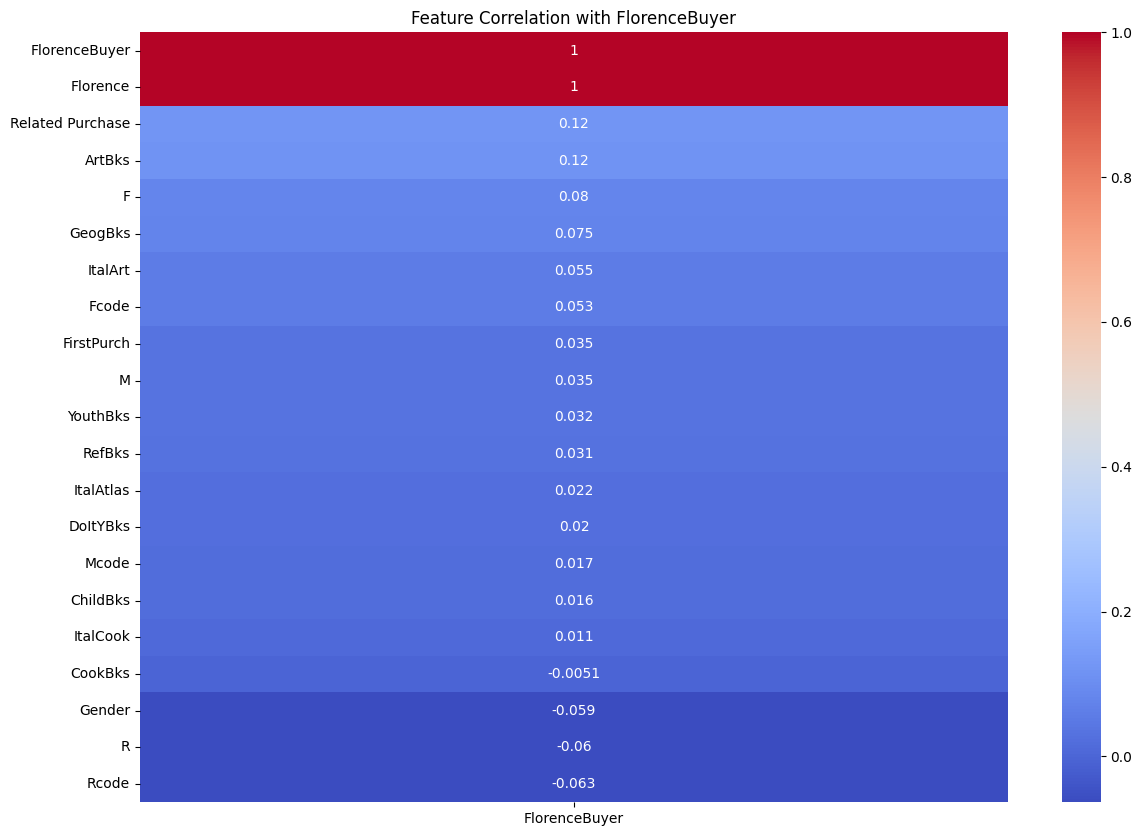

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("C:\\Users\\hangu\\Downloads\\CharlesBookClub.csv")

# Drop irrelevant columns
df_cleaned = df.drop(columns=['Seq#', 'ID#'])

# Create binary target column
df_cleaned['FlorenceBuyer'] = df_cleaned['Yes_Florence']

# Drop the original Yes/No columns
df_cleaned = df_cleaned.drop(columns=['Yes_Florence', 'No_Florence'])

# Check for missing values
print("Missing values:", df_cleaned.isnull().sum().sum())

# Correlation heatmap to identify influential features
plt.figure(figsize=(14, 10))
corr = df_cleaned.corr()
sns.heatmap(corr[['FlorenceBuyer']].sort_values(by='FlorenceBuyer', ascending=False), annot=True, cmap='coolwarm')
plt.title("Feature Correlation with FlorenceBuyer")
plt.show()

Checkpoint Q1:

Which features appear to influence specialty travel purchases?

Customers who are interested in Italian-themed books are more likely to buy the Florence travel book. In particular, people who purchased books about Italian art (ItalArt), Italian cooking (ItalCook), or Italian maps (ItalAtlas) showed a strong connection to buying the Florence book. Other types of books like geography and reference books also had a smaller influence. Overall, customers who like travel or Italy-related content are more likely to make this specialty purchase.

# Part B: Modeling Florence Book Purchase

Accuracy: 1.0
Precision: 1.0
Recall: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1099
           1       1.00      1.00      1.00       101

    accuracy                           1.00      1200
   macro avg       1.00      1.00      1.00      1200
weighted avg       1.00      1.00      1.00      1200



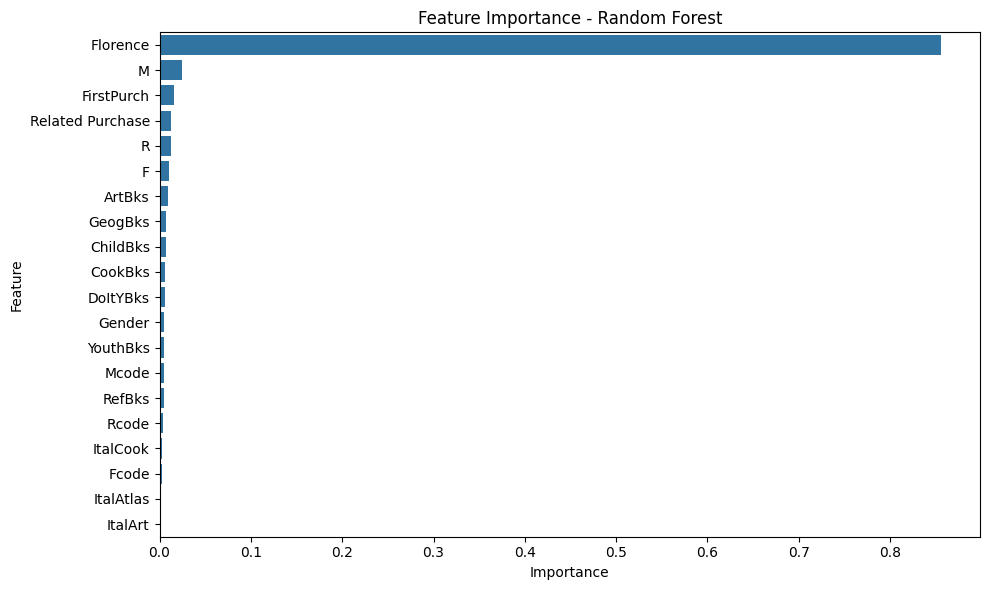

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report

# Load the data
df = pd.read_csv("C:\\Users\\hangu\\Downloads\\CharlesBookClub.csv")
df = df.drop(columns=["Seq#", "ID#"])
df["FlorenceBuyer"] = df["Yes_Florence"]
df = df.drop(columns=["Yes_Florence", "No_Florence"])

# Split data into features and target
X = df.drop(columns=["FlorenceBuyer"])
y = df["FlorenceBuyer"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Train the Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Evaluate model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))

# Feature importance
importances = model.feature_importances_
features = X.columns
importance_df = pd.DataFrame({"Feature": features, "Importance": importances})
importance_df = importance_df.sort_values(by="Importance", ascending=False)

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=importance_df)
plt.title("Feature Importance - Random Forest")
plt.tight_layout()
plt.show()


Checkpoint Q2:

Why might an ensemble method outperform a simple logistic regression here?


The method that i use is Random Forest because it often work better than logistic regression and they can handle more complex patterns in the data. Logistic regression is a simple model that looks for straight-line relationships between features and the outcome, which may miss important details. In contrast, Random Forest uses many decision trees to find patterns, even if they are non-linear or involve interactions between features. Since customer behavior is usually influenced by a mix of factors that work together in complex ways, an ensemble method is better suited to capture those relationships and make more accurate predictions.

In [6]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules
import warnings
warnings.filterwarnings('ignore')


# Load the data
df = pd.read_csv("C:\\Users\\hangu\\Downloads\\CharlesBookClub.csv")
df = df.drop(columns=["Seq#", "ID#", "Yes_Florence", "No_Florence"])

# Filter for only book genre columns
genre_columns = [col for col in df.columns if "Bks" in col or "Ital" in col or "Cook" in col or "Atlas" in col or "Art" in col]
genre_df = df[genre_columns]

# Convert genre data to binary
genre_binary = genre_df.applymap(lambda x: 1 if x > 0 else 0)

# Apply Apriori algorithm
frequent_itemsets = apriori(genre_binary, min_support=0.01, use_colnames=True)

# Generate association rules
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)

# Show top 3 rules sorted by lift
top_rules = rules.sort_values(by='lift', ascending=False).head(3)
print(top_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])


             antecedents                  consequents  support  confidence  \
1652  (ArtBks, ItalCook)           (CookBks, ItalArt)   0.0115    0.335766   
1649  (CookBks, ItalArt)           (ArtBks, ItalCook)   0.0115    0.362205   
1656           (ItalArt)  (CookBks, ArtBks, ItalCook)   0.0115    0.265896   

           lift  
1652  10.575320  
1649  10.575320  
1656  10.530533  
